In [1]:
import pandas as pd

df = pd.read_csv("exp_survey.csv")

In [2]:
df.head(2)

,Gender,Age,edu,I am familiar with the Blackbox nature of Machine learning,exp_1,exp_2,exp_3,exp_4,exp_5,satis_1,...,satis_4,satis_5,satis_6,trust_1,trust_2,trust_3,trust_4,trust_5,trust_6,group
0,Female,33,Undertaking Doctoral Studies,Yes,Neutral,Agree,Disagree,Neutral,Neutral,Agree,...,Agree,Agree,Agree,Agree,Agree,Strongly Agree,Agree,Agree,Agree,exp
1,Female,44,Undertaking Doctoral Studies,No,Strongly disagree,Strongly disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,...,Strongly Disagree,Strongly disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,exp


In [3]:
df.shape

(75, 22)

In [4]:
df.columns

Index(['Gender', 'Age', 'edu',
       'I am familiar with the Blackbox nature of Machine learning        ',
       'exp_1', 'exp_2', 'exp_3', 'exp_4', 'exp_5', 'satis_1', 'satis_2',
       'satis_3', 'satis_4', 'satis_5', 'satis_6', 'trust_1', 'trust_2',
       'trust_3', 'trust_4', 'trust_5', 'trust_6', 'group'],
      dtype='object')

In [5]:
df.columns = df.columns.str.strip()

df.rename(columns={
	'I am familiar with the Blackbox nature of Machine learning': 'fam'
}, inplace=True)

In [6]:
df.columns

Index(['Gender', 'Age', 'edu', 'fam', 'exp_1', 'exp_2', 'exp_3', 'exp_4',
       'exp_5', 'satis_1', 'satis_2', 'satis_3', 'satis_4', 'satis_5',
       'satis_6', 'trust_1', 'trust_2', 'trust_3', 'trust_4', 'trust_5',
       'trust_6', 'group'],
      dtype='object')

In [7]:
df.head(2)

,Gender,Age,edu,fam,exp_1,exp_2,exp_3,exp_4,exp_5,satis_1,...,satis_4,satis_5,satis_6,trust_1,trust_2,trust_3,trust_4,trust_5,trust_6,group
0,Female,33,Undertaking Doctoral Studies,Yes,Neutral,Agree,Disagree,Neutral,Neutral,Agree,...,Agree,Agree,Agree,Agree,Agree,Strongly Agree,Agree,Agree,Agree,exp
1,Female,44,Undertaking Doctoral Studies,No,Strongly disagree,Strongly disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,...,Strongly Disagree,Strongly disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,Strongly Disagree,exp


In [9]:
likert_map = {
    'Strongly Agree': 5,
    'Strongly agree': 5,
    'Agree': 4,
    'Neutral': 3,
    'Disagree': 2,
    'Strongly Disagree': 1,
    'Strongly disagree': 1
}

# Columns containing your questionnaire items
items = [
	'exp_1', 'exp_2', 'exp_3', 'exp_4', 'exp_5',
	'satis_1', 'satis_2', 'satis_3', 'satis_4', 'satis_5', 'satis_6',
	'trust_1', 'trust_2', 'trust_3', 'trust_4', 'trust_5', 'trust_6']

df[items] = df[items].replace(likert_map)

/var/folders/qr/qqkx12110914k3tn4fmdfr480000gn/T/ipykernel_47898/72306544.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[items] = df[items].replace(likert_map)


In [10]:
df.head(2)

,Gender,Age,edu,fam,exp_1,exp_2,exp_3,exp_4,exp_5,satis_1,...,satis_4,satis_5,satis_6,trust_1,trust_2,trust_3,trust_4,trust_5,trust_6,group
0,Female,33,Undertaking Doctoral Studies,Yes,3,4.0,2,3,3,4,...,4,4,4,4,4,5,4,4,4,exp
1,Female,44,Undertaking Doctoral Studies,No,1,1.0,1,1,1,1,...,1,1,1,1,1,1,1,1,1,exp


In [24]:
import pandas as pd
import numpy as np


# -----------------------------
# Cronbach's alpha
# -----------------------------

def cronbach_alpha(data):
    data = data.dropna()

    k = data.shape[1]

    item_variances = data.var(axis=0, ddof=1)
    total_score = data.sum(axis=1)
    total_variance = total_score.var(ddof=1)

    alpha = (k / (k - 1)) * (
        1 - item_variances.sum() / total_variance
    )

    return alpha


# -----------------------------
# Item analysis
# -----------------------------

def item_analysis(data):

    data = data.dropna()

    results = []

    full_alpha = cronbach_alpha(data)

    for item in data.columns:

        # All other items
        other_items = data.drop(columns=item)

        # Total score excluding this item
        total_without_item = other_items.sum(axis=1)

        # Corrected item-total correlation
        item_total_corr = data[item].corr(total_without_item)

        # Alpha if this item is removed
        alpha_if_deleted = cronbach_alpha(other_items)

        results.append({
            'Item': item,
            'Corrected Item-Total Correlation': item_total_corr,
            'Alpha if Item Deleted': alpha_if_deleted,
            'Current Alpha': full_alpha
        })

    return pd.DataFrame(results)


# -----------------------------
# Your three scales
# -----------------------------

experience_items = [
    'exp_1', 'exp_2', 'exp_3', 'exp_4', 'exp_5'
]

satisfaction_items = [
    'satis_1', 'satis_2', 'satis_3',
    'satis_4', 'satis_5', 'satis_6'
]

trust_items = [
    'trust_1', 'trust_2', 'trust_3',
    'trust_4', 'trust_5', 'trust_6'
]


# -----------------------------
# Run analysis
# -----------------------------

experience_analysis = item_analysis(df[experience_items])
satisfaction_analysis = item_analysis(df[satisfaction_items])
trust_analysis = item_analysis(df[trust_items])


print("EXPERIENCE")
print(experience_analysis.round(3).to_string(index=False))

print("\nSATISFACTION")
print(satisfaction_analysis.round(3).to_string(index=False))

print("\nTRUST")
print(trust_analysis.round(3).to_string(index=False))

EXPERIENCE
 Item  Corrected Item-Total Correlation  Alpha if Item Deleted  Current Alpha
exp_1                             0.412                  0.501          0.583
exp_2                             0.433                  0.470          0.583
exp_3                             0.325                  0.537          0.583
exp_4                             0.243                  0.578          0.583
exp_5                             0.310                  0.545          0.583

SATISFACTION
   Item  Corrected Item-Total Correlation  Alpha if Item Deleted  Current Alpha
satis_1                             0.328                  0.610          0.639
satis_2                             0.367                  0.596          0.639
satis_3                             0.357                  0.600          0.639
satis_4                             0.388                  0.588          0.639
satis_5                             0.348                  0.603          0.639
satis_6                    

In [25]:
# Create composite variables using the mean of each item's responses

df['exp_com'] = df[['exp_1', 'exp_2', 'exp_3', 'exp_4', 'exp_5']].mean(axis=1)

df['sat_comp'] = df[['satis_1', 'satis_2', 'satis_3', 'satis_4', 'satis_5', 'satis_6']].mean(axis=1)

df['trust_com'] = df[['trust_1', 'trust_2', 'trust_3', 'trust_4', 'trust_5', 'trust_6']].mean(axis=1)

In [26]:
print(df[['exp_com', 'sat_comp', 'trust_com']].describe())

         exp_com   sat_comp  trust_com
count  75.000000  75.000000  75.000000
mean    3.880000   3.964444   3.966667
std     0.608054   0.545452   0.556156
min     1.000000   1.000000   1.000000
25%     3.800000   3.833333   3.833333
50%     4.000000   4.000000   4.000000
75%     4.200000   4.166667   4.333333
max     5.000000   4.833333   4.666667


In [27]:
from scipy.stats import shapiro

# Overall normality test for exp_com
exp = df['exp_com'].dropna()

stat, p = shapiro(exp)

print("Overall Sample")
print(f"Shapiro-Wilk statistic = {stat:.3f}")
print(f"p-value = {p:.3f}")
print(f"Skewness = {exp.skew():.3f}")
print(f"Kurtosis = {exp.kurtosis():.3f}")

Overall Sample
Shapiro-Wilk statistic = 0.798
p-value = 0.000
Skewness = -2.186
Kurtosis = 7.603


In [28]:
!pip install scipy

In [30]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# Variables for correlation
variables = ['exp_com', 'sat_comp', 'trust_com']

# Create correlation and p-value matrices
r_matrix = pd.DataFrame(
    np.nan,
    index=variables,
    columns=variables
)

p_matrix = pd.DataFrame(
    np.nan,
    index=variables,
    columns=variables
)

for i in range(len(variables)):
    for j in range(len(variables)):

        x = df[variables[i]]
        y = df[variables[j]]

        # Pairwise complete observations
        valid = x.notna() & y.notna()

        r, p = pearsonr(
            x[valid].to_numpy(),
            y[valid].to_numpy()
        )

        r_matrix.iloc[i, j] = r
        p_matrix.iloc[i, j] = p


print("Pearson Correlation Matrix")
print(r_matrix.round(3))

print("\nP-value Matrix")
print(p_matrix.round(3))

Pearson Correlation Matrix
           exp_com  sat_comp  trust_com
exp_com      1.000     0.718      0.633
sat_comp     0.718     1.000      0.620
trust_com    0.633     0.620      1.000

P-value Matrix
           exp_com  sat_comp  trust_com
exp_com        0.0       0.0        0.0
sat_comp       0.0       0.0        0.0
trust_com      0.0       0.0        0.0


In [31]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 11.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [statsmodels] [statsmodels]


In [32]:
import statsmodels.api as sm
import pandas as pd

# Dependent variable
Y = df['trust_com']

# Independent variables
X = df[['exp_com', 'sat_comp']]

# Add intercept
X = sm.add_constant(X)

# Keep complete cases
reg_data = pd.concat([Y, X], axis=1).dropna()

# Fit regression model
model = sm.OLS(
	reg_data['trust_com'],
	reg_data[['const', 'exp_com', 'sat_comp']]
).fit()

# Full regression output
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              trust_com   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     30.28
Date:                Wed, 30 Sep 2026   Prob (F-statistic):           2.86e-10
Time:                        18:47:38   Log-Likelihood:                -39.023
No. Observations:                  75   AIC:                             84.05
Df Residuals:                      72   BIC:                             91.00
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2106      0.363      3.331      0.0

In [33]:
!pip install matplotlib
!pip install seaborn

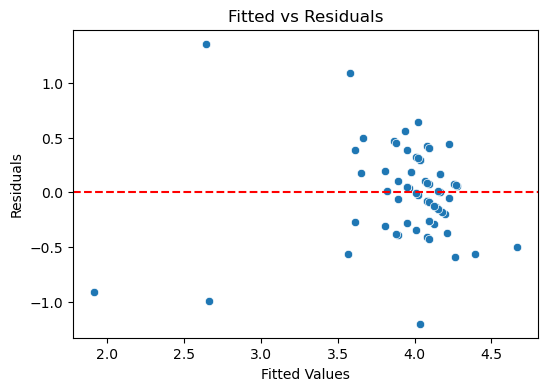

Shapiro-Wilk Test for Residuals: stat=0.9675, p=0.0510 -> Normal


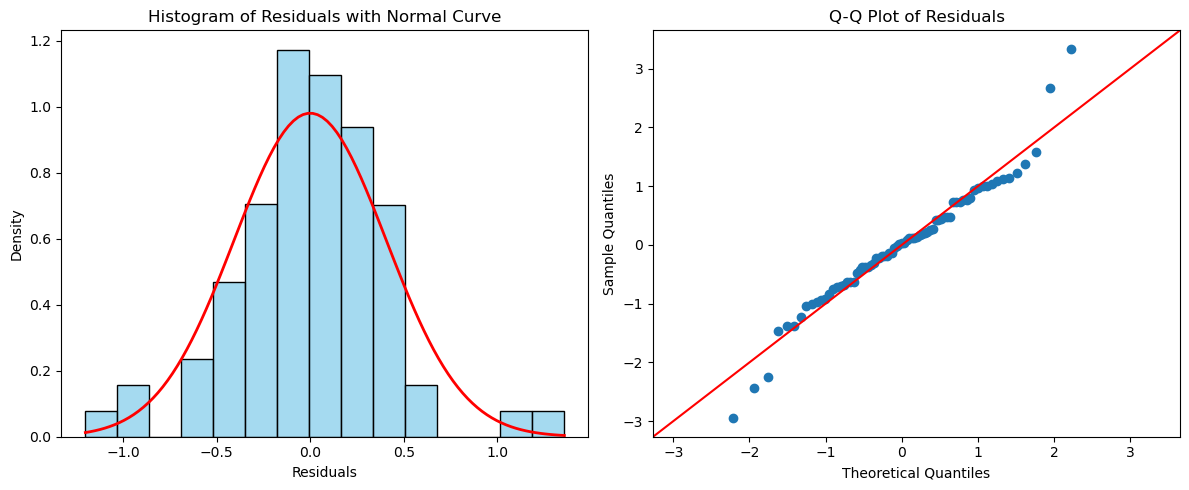

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

# Assuming 'model' is your fitted OLS model
residuals = model.resid
fitted = model.fittedvalues

# 1. Fitted vs Residual plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Fitted vs Residuals')
plt.show()

# 2. Shapiro-Wilk test for residuals
stat, p = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test for Residuals: stat={stat:.4f}, p={p:.4f} ->", "Normal" if p>0.05 else "Not Normal")

# 3 & 4. Histogram with bell curve + Q-Q plot
plt.figure(figsize=(12,5))

# Histogram with bell curve
plt.subplot(1,2,1)
sns.histplot(residuals, kde=False, stat='density', bins=15, color='skyblue', edgecolor='black')
mu, std = np.mean(residuals), np.std(residuals)
x = np.linspace(residuals.min(), residuals.max(), 100)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r', linewidth=2)
plt.title('Histogram of Residuals with Normal Curve')
plt.xlabel('Residuals')
plt.ylabel('Density')

# Q-Q plot
plt.subplot(1,2,2)
sm.qqplot(residuals, line='45', fit=True, ax=plt.gca())
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()